# Deffuant model: how bounded confidence shapes opinions

Learning objective: see how random pairwise compromise can reduce disagreement while leaving distinct opinion groups.

People may be willing to reconsider their opinions only when a neighbor's view is sufficiently close. A network lets us ask theoretical questions such as:

- Does local compromise lead to consensus?
- How does willingness to interact affect the final opinions?
- Can disagreement persist even on a connected social network?

The value of the model is that it makes these assumptions explicit and lets us examine their consequences.

## The Deffuant bounded-confidence model.

Each agent $i$ has a continuous opinion $x_i(t)\in[0,1]$. At each attempted interaction, choose one undirected network edge $\{i,j\}$ uniformly at random.

The pair compromises only when

$$
|x_i(t)-x_j(t)| < \epsilon.
$$

If compatible, both opinions change simultaneously using their old values:

$$
\begin{aligned}
x_i(t+1)&=x_i(t)+\mu\bigl[x_j(t)-x_i(t)\bigr],\\
x_j(t+1)&=x_j(t)+\mu\bigl[x_i(t)-x_j(t)\bigr].
\end{aligned}
$$

Otherwise neither opinion changes. All other agents keep their opinions. The confidence bound $\epsilon$ controls willingness to interact; the compromise parameter $\mu$ controls how far each agent moves.

### Conventions used here

- **Opinion space:** continuous values in $[0,1]$.
- **Population:** 100 agents by default; adjustable through `N_AGENTS`.
- **Network structure:** one fixed, simple, connected, undirected Watts–Strogatz network, initially with two neighbors on each side and rewiring probability 0.10.
- **Initial state:** independent uniform draws on $[0,1]$ with a visible fixed seed.
- **Pair selection:** sample uniformly from all network edges, with replacement; rejected pairs still count as attempts.
- **Update schedule:** asynchronous across pairs; both members of a selected pair update from their old values.
- **Confidence boundary:** strict inequality $|x_i-x_j|<\epsilon$; equality is rejected.
- **Time:** $t$ counts iterations, with one iteration equal to one attempted pair interaction (including rejected interactions). Figure time axes show this count. One sweep groups `N_AGENTS` attempts; agents need not participate equally often.
- **Simulation horizon:** exactly `N_SWEEPS * N_AGENTS` iterations (50,000 with the default parameters), recording the initial state and every sweep boundary (every 100 iterations by default); no early stopping.
- **Observables:** opinion trajectories, opinion range, and final opinion distribution.
- **Consensus criterion:** global opinion range strictly smaller than `CONSENSUS_TOLERANCE`, evaluated at recorded times. The first recorded detection may be later than the actual threshold crossing.
- **Parameter ranges:** integer `N_AGENTS` >= 3 and `N_SWEEPS` >= 0; integer $1\leq$ `NEIGHBORS_ON_EACH_SIDE` $<N/2$; rewiring probability and each confidence bound in $[0,1]$; $0<\mu\leq1/2$; `CONSENSUS_TOLERANCE` > 0; positive integer `MAX_NETWORK_ATTEMPTS`.

This is the network-restricted version of the Deffuant model. The original well-mixed pair selection is recovered on a complete graph. Isolated agents, if supplied to the simulation, never participate and keep their opinions.

Symmetric compromise preserves the arithmetic mean in every realization, even when some interactions are rejected. If global consensus occurs, its limiting value is that initial mean. Connectedness of the social network alone does not guarantee consensus when confidence restricts interactions.

In [1]:
import random

import igraph as ig
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters
N_AGENTS = 100
N_SWEEPS = 500
NEIGHBORS_ON_EACH_SIDE = 2
REWIRING_PROBABILITY = 0.10
CONFIDENCE_BOUND = 0.2
COMPARISON_CONFIDENCE_BOUND = 0.60
COMPROMISE_PARAMETER = 0.3
CONSENSUS_TOLERANCE = 0.01

# Match the voter network and layout; seed continuous opinions and interactions separately.
NETWORK_SEED = 2026
MAX_NETWORK_ATTEMPTS = 20
OPINION_SEED = 7986
LAYOUT_SEED = 2028
INTERACTION_SEED = 1324

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## 1. Create the social network

We use `igraph` to create, store, lay out, and draw a small-world network. The parameter `NEIGHBORS_ON_EACH_SIDE = 2` starts each agent with two lattice neighbors on either side, as in `2_voter.ipynb`. We use the same deterministic retries to obtain a simple, connected network, and reproduce the same layout.

The `python-igraph` generator uses a small-world rewiring variant. This synthetic topology is a convenient theoretical influence structure, not a reconstruction of a real social network.

The force-directed layout affects only the drawing, not the interaction rule or dynamics. Fixed seeds make the generated network and layout reproducible within the specified software environment; results may differ across library versions.

In [2]:
# Match the graph generation and seed rule in 2_voter.ipynb.
for attempt in range(MAX_NETWORK_ATTEMPTS):
    graph_seed = NETWORK_SEED + 1_000 * NEIGHBORS_ON_EACH_SIDE + attempt
    ig.set_random_number_generator(random.Random(graph_seed))
    graph_ig = ig.Graph.Watts_Strogatz(
        dim=1, size=N_AGENTS, nei=NEIGHBORS_ON_EACH_SIDE,
        p=REWIRING_PROBABILITY,
    )
    if graph_ig.is_simple() and graph_ig.is_connected():
        break
else:
    raise RuntimeError("No connected network found; try another NETWORK_SEED.")

layout_rng = np.random.default_rng(LAYOUT_SEED + NEIGHBORS_ON_EACH_SIDE)
layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
layout = graph_ig.layout_fruchterman_reingold(
    seed=layout_start.tolist(), niter=1000,
)

opinion_rng = np.random.default_rng(OPINION_SEED)
initial_opinions = opinion_rng.uniform(0.0, 1.0, size=N_AGENTS)

print(f"Agents: {graph_ig.vcount()}")
print(f"Connections: {graph_ig.ecount()}")
print(f"Connected: {graph_ig.is_connected()}")

Agents: 100
Connections: 200
Connected: True


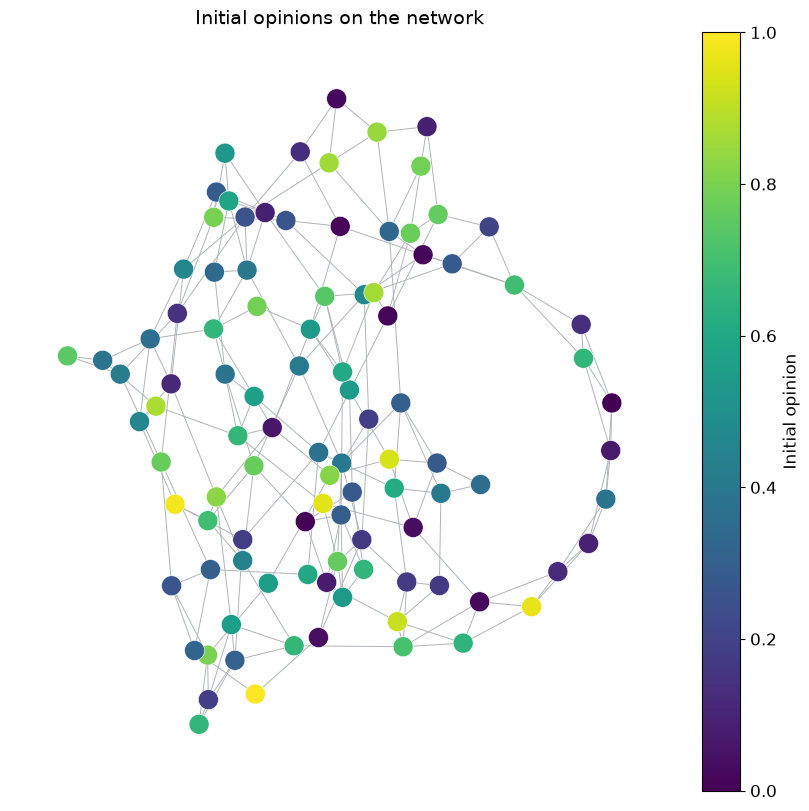

In [3]:
opinion_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
opinion_cmap = plt.colormaps["viridis"]
opinion_color_scale = plt.cm.ScalarMappable(
    norm=opinion_norm,
    cmap=opinion_cmap,
)


def draw_opinion_network(ax, opinions, title, vertex_size):
    """Draw opinions on the igraph network using vertex-ID order."""
    vertex_colors = [
        mcolors.to_hex(opinion_cmap(opinion_norm(value)))
        for value in opinions
    ]

    ig.plot(
        graph_ig,
        target=ax,
        layout=layout,
        vertex_color=vertex_colors,
        vertex_size=vertex_size,
        vertex_frame_color="white",
        vertex_frame_width=0.4,
        vertex_label=None,
        edge_color="#b0b4b8",
        edge_width=0.7,
        autocurve=False,
    )
    ax.set_title(title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
draw_opinion_network(
    ax,
    initial_opinions,
    "Initial opinions on the network",
    vertex_size=20,
)
fig.colorbar(opinion_color_scale, ax=ax, label="Initial opinion")
# plt.savefig("./figures/deffuant_initial_network.pdf")
plt.show()

## 2. Translate the theory into code

The edge list tells us which pairs can meet. The confidence test uses the opinions at the moment of interaction.

We cache both old values before updating either agent. The pair sum is unchanged:

$$
x_i(t+1)+x_j(t+1)=x_i(t)+x_j(t).
$$

At $\mu=1/2$, a compatible pair meets at its midpoint. Smaller values produce partial compromise. No change occurs at $\epsilon=0$ under the strict threshold convention.

In [4]:
edge_array = np.asarray(graph_ig.get_edgelist(), dtype=int).reshape(-1, 2)
initial_mean = initial_opinions.mean()


def compromise_pair(opinions, i, j, confidence_bound, mu):
    """Update a compatible pair in place from its two old opinions."""
    old_i, old_j = opinions[i], opinions[j]
    if abs(old_i - old_j) < confidence_bound:
        opinions[i] = old_i + mu * (old_j - old_i)
        opinions[j] = old_j + mu * (old_i - old_j)


# Hand-check partial compromise: 0 and 0.5 become 0.125 and 0.375.
test_pair = np.array([0.0, 0.5])
compromise_pair(test_pair, 0, 1, confidence_bound=0.75, mu=0.25)

# Exactly on the confidence boundary: reject the interaction.
boundary_pair = np.array([0.0, 0.5])
compromise_pair(boundary_pair, 0, 1, confidence_bound=0.5, mu=0.5)

print(f"Initial arithmetic mean: {initial_mean:.6f}")

Initial arithmetic mean: 0.449895


## 3. Run asynchronous Deffuant updates

Each sweep samples N_AGENTS edges independently with replacement. These attempts execute sequentially, so later pairs see changes made by earlier pairs.

The function keeps the input opinions intact and records one snapshot per sweep. Drawing every edge index before processing a sweep also lets us reuse precisely the same attempted interactions in the confidence comparison.

In [5]:
def simulate_deffuant(edges, initial_state, n_sweeps, confidence_bound, mu, rng):
    """Return opinions at sweep boundaries, including the initial state."""
    opinions = np.asarray(initial_state, dtype=float).copy()

    history = np.empty((n_sweeps + 1, len(opinions)))
    history[0] = opinions

    for sweep in range(1, n_sweeps + 1):
        if len(edges):
            edge_indices = rng.integers(len(edges), size=len(opinions))
            for edge_index in edge_indices:
                i, j = edges[edge_index]
                compromise_pair(opinions, i, j, confidence_bound, mu)
        history[sweep] = opinions

    return history


opinion_history = simulate_deffuant(
    edge_array, initial_opinions, N_SWEEPS,
    CONFIDENCE_BOUND, COMPROMISE_PARAMETER,
    np.random.default_rng(INTERACTION_SEED),
)

final_opinions = opinion_history[-1]

## 4. Compare the initial and final states

Both panels use the same network layout and color scale. This makes changes in opinions visible without confusing them with changes in node position.

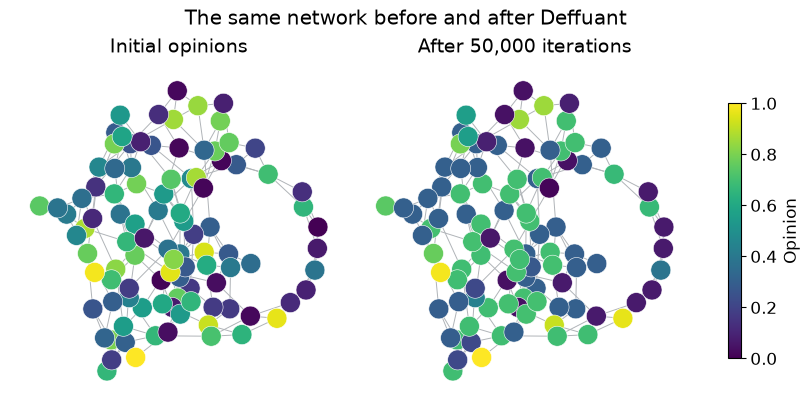

In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4),
    layout="constrained",
)

states = [
    (initial_opinions, "Initial opinions"),
    (final_opinions, f"After {N_SWEEPS * N_AGENTS:,} iterations"),
]

for ax, (opinions, title) in zip(axes, states):
    draw_opinion_network(
        ax,
        opinions,
        title,
        vertex_size=20,
    )

fig.colorbar(
    opinion_color_scale,
    ax=axes,
    label="Opinion",
    shrink=0.75,
)
fig.suptitle(
    "The same network before and after Deffuant"
)
# plt.savefig("./figures/deffuant_final_network.pdf") 
plt.show()

## 5. A typical analysis: does disagreement disappear?

We follow individual opinions and the global opinion range:

$$
R(t)=\max_i x_i(t)-\min_i x_i(t),
$$

where $t$ counts attempted pair interactions. The horizontal coordinate is $t$, the actual number of attempted interactions. The plots show the initial state and one snapshot every `N_AGENTS` iterations (100 by default). Convex compromise cannot increase this range, but confidence restrictions can leave it positive.

The dashed mean line is a conservation reference. It is the consensus value only if consensus occurs. A plateau over a finite observation window does not by itself establish a limiting state or an exact number of opinion clusters.

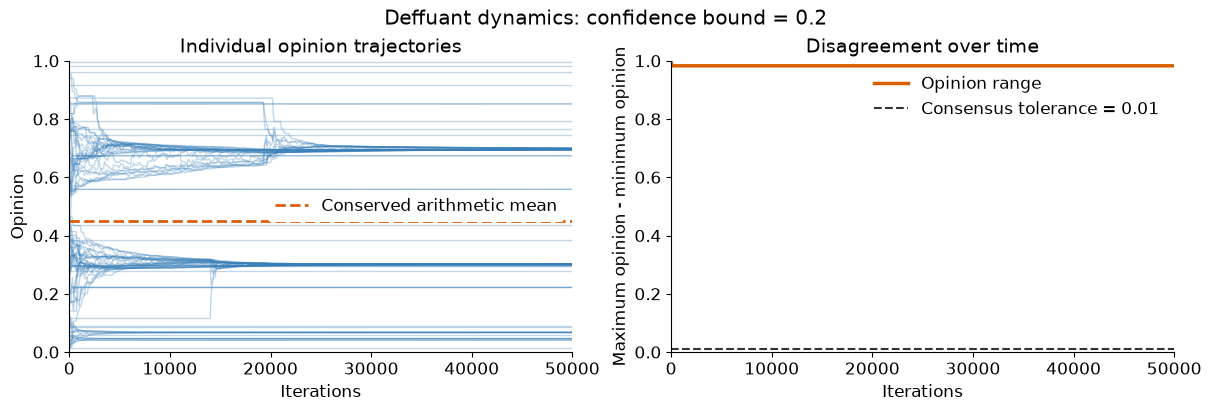

The trajectory did not reach the consensus tolerance.
Initial mean: 0.449895; final mean: 0.449895
Final opinion range: 0.982707
Largest remaining gap on a compatible edge: 0.00143887


In [7]:
iterations = np.arange(N_SWEEPS + 1) * N_AGENTS
opinion_range = np.ptp(opinion_history, axis=1)
consensus_indices = np.flatnonzero(opinion_range < CONSENSUS_TOLERANCE)
first_consensus_iteration = int(iterations[consensus_indices[0]]) if consensus_indices.size else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(iterations, opinion_history, color="#377eb8", alpha=0.30, linewidth=1)
axes[0].axhline(
    initial_mean, color="#d95f02", linestyle="--",
    linewidth=2, label="Conserved arithmetic mean",
)
axes[0].set(
    title="Individual opinion trajectories", xlabel="Iterations", ylabel="Opinion",
    ylim=(0, 1), xlim=(0, max(1, N_SWEEPS * N_AGENTS)),
)
axes[0].legend(frameon=True, facecolor="white", edgecolor="none", framealpha=1)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(
    iterations, opinion_range, color="#d95f02", linewidth=2.5, label="Opinion range",
)
axes[1].axhline(
    CONSENSUS_TOLERANCE, color="#333333", linestyle="--",
    label=f"Consensus tolerance = {CONSENSUS_TOLERANCE}",
)
if first_consensus_iteration is not None:
    axes[1].axvline(
        first_consensus_iteration, color="#377eb8", linestyle=":",
        label=f"First recorded: iteration {first_consensus_iteration:,}",
    )
axes[1].set(
    title="Disagreement over time", xlabel="Iterations",
    ylabel="Maximum opinion - minimum opinion",
    ylim=(0, 1), xlim=(0, max(1, N_SWEEPS * N_AGENTS)),
)
axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Deffuant dynamics: confidence bound = {CONFIDENCE_BOUND:g}")
# plt.savefig("./figures/deffuant_opinions_0_2.pdf")
plt.show()

if first_consensus_iteration is None:
    print("The trajectory did not reach the consensus tolerance.")
else:
    print("First recorded iteration below tolerance:", first_consensus_iteration)
print(f"Initial mean: {initial_mean:.6f}; final mean: {final_opinions.mean():.6f}")
print(f"Final opinion range: {opinion_range[-1]:.6f}")

edge_gaps = np.abs(final_opinions[edge_array[:, 0]] - final_opinions[edge_array[:, 1]])
compatible_gaps = edge_gaps[edge_gaps < CONFIDENCE_BOUND]
print(
    "Largest remaining gap on a compatible edge:",
    f"{np.max(compatible_gaps, initial=0.0):.6g}",
)

## 6. One focused experiment: change the confidence bound

We reuse the same network, initial opinions, compromise parameter, and attempted edge sequence. Only the confidence bound changes. Resetting the interaction generator to the same seed achieves this because sampling never depends on whether an interaction was accepted.

The panels show final opinion distributions using identical histogram bins and scales. Histogram peaks illustrate concentrations at the selected resolution; they are not an exact cluster count. These two seeded examples do not establish a universal threshold for consensus.

A separate figure repeats the section 5 analysis for `COMPARISON_CONFIDENCE_BOUND`: individual opinion trajectories and the global opinion range over time, using the same axis limits and reference lines.


Confidence 0.2: final range = 0.982707; consensus detected = False
Confidence 0.6: final range = 0.000000; consensus detected = True


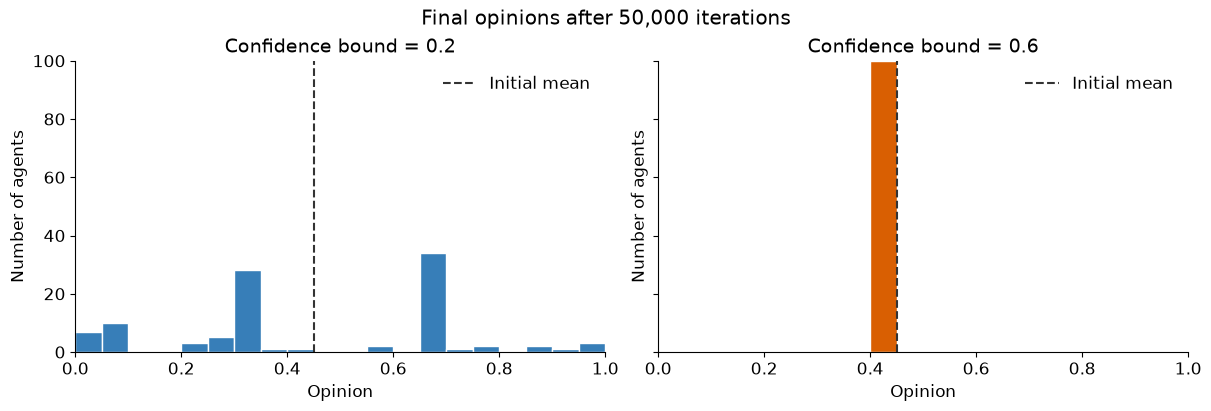

In [8]:
comparison_history = simulate_deffuant(
    edge_array, initial_opinions, N_SWEEPS,
    COMPARISON_CONFIDENCE_BOUND, COMPROMISE_PARAMETER,
    np.random.default_rng(INTERACTION_SEED),
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4), sharex=True, sharey=True, layout="constrained",
)
scenarios = [
    (CONFIDENCE_BOUND, opinion_history, "#377eb8"),
    (COMPARISON_CONFIDENCE_BOUND, comparison_history, "#d95f02"),
]
bins = np.linspace(0, 1, 21)
for ax, (confidence_bound, history, color) in zip(axes, scenarios):
    ax.hist(history[-1], bins=bins, color=color, edgecolor="white")
    ax.axvline(initial_mean, color="#333333", linestyle="--", label="Initial mean")
    ax.set(
        title=f"Confidence bound = {confidence_bound:g}",
        xlabel="Opinion", ylabel="Number of agents",
        xlim=(0, 1), ylim=(0, N_AGENTS),
    )
    ax.legend(frameon=False)
    final_range = np.ptp(history[-1])
    print(
        f"Confidence {confidence_bound:g}: final range = {final_range:.6f}; "
        f"consensus detected = {final_range < CONSENSUS_TOLERANCE}"
    )
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Final opinions after {N_SWEEPS * N_AGENTS:,} iterations")
plt.show()

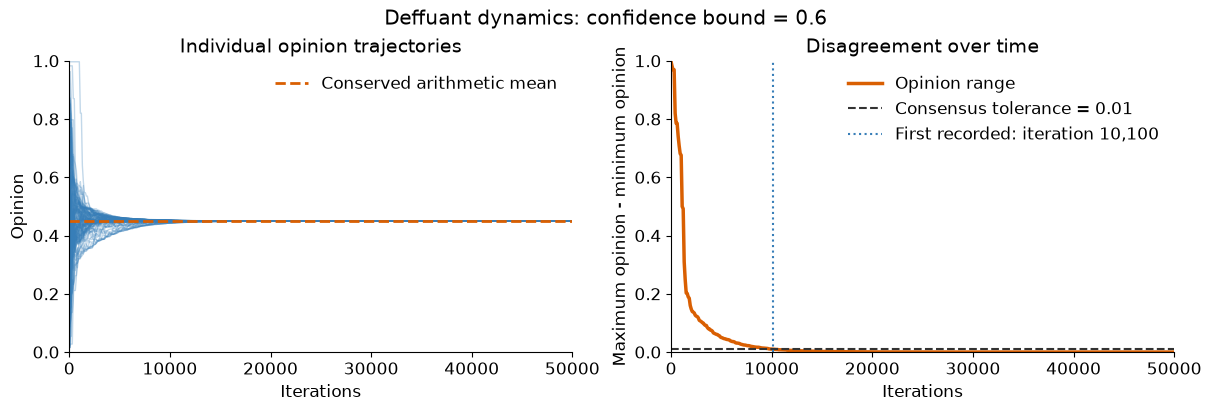

In [9]:
iterations = np.arange(N_SWEEPS + 1) * N_AGENTS
comparison_range = np.ptp(comparison_history, axis=1)
comparison_consensus_indices = np.flatnonzero(comparison_range < CONSENSUS_TOLERANCE)
comparison_first_consensus_iteration = int(iterations[comparison_consensus_indices[0]]) if comparison_consensus_indices.size else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(iterations, comparison_history, color="#377eb8", alpha=0.30, linewidth=1)
axes[0].axhline(
    initial_mean, color="#d95f02", linestyle="--",
    linewidth=2, label="Conserved arithmetic mean",
)
axes[0].set(
    title="Individual opinion trajectories", xlabel="Iterations", ylabel="Opinion",
    ylim=(0, 1), xlim=(0, max(1, N_SWEEPS * N_AGENTS)),
)
axes[0].legend(frameon=True, facecolor="white", edgecolor="none", framealpha=1)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(
    iterations, comparison_range, color="#d95f02", linewidth=2.5, label="Opinion range",
)
axes[1].axhline(
    CONSENSUS_TOLERANCE, color="#333333", linestyle="--",
    label=f"Consensus tolerance = {CONSENSUS_TOLERANCE}",
)
if comparison_first_consensus_iteration is not None:
    axes[1].axvline(
        comparison_first_consensus_iteration, color="#377eb8", linestyle=":",
        label=f"First recorded: iteration {comparison_first_consensus_iteration:,}",
    )
axes[1].set(
    title="Disagreement over time", xlabel="Iterations",
    ylabel="Maximum opinion - minimum opinion",
    ylim=(0, 1), xlim=(0, max(1, N_SWEEPS * N_AGENTS)),
)
axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Deffuant dynamics: confidence bound = {COMPARISON_CONFIDENCE_BOUND:g}")
# plt.savefig("./figures/deffuant_final_opinion_0_6.pdf")
plt.show()


## Interpretation and limitations

Symmetric pairwise compromise preserves the arithmetic mean and cannot increase global variance or opinion range. The confidence test controls which social ties actually transmit influence.

The baseline and confidence comparison illustrate how this mechanism can produce different amounts of agreement on the same connected network. A finite simulation can show separated concentrations or near-consensus; it does not prove that every trajectory with these parameters has reached its asymptotic state.

On a sparse network, agents with similar opinions need not be directly linked. Connected components of the social graph, compatible-edge components, and concentrations in opinion space are different objects.

The model omits changing relationships, external information, asymmetric persuasion, individual confidence bounds, and multidimensional beliefs. Its outcomes follow from these theoretical assumptions and should not be interpreted as predictions of real populations.


### Reference

Deffuant, G., Neau, D., Amblard, F., & Weisbuch, G. (2000). *Mixing beliefs among interacting agents*. Advances in Complex Systems, 3(1–4), 87–98. [doi:10.1142/S0219525900000078](https://doi.org/10.1142/S0219525900000078).